In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
import re
from bs4 import BeautifulSoup

sns.set_style('darkgrid')

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1",
    path="IMDB Dataset.csv",
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
nltk.download("punkt")

nltk.download("punkt_tab")

nltk.download("wordnet")

nltk.download("omw-1.4")

nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [5]:
def preprocess_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z\s\']", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    processed_tokens = []
    for token in tokens:
        if (
            token not in stop_words and len(token) > 1
        ):
            lemma = lemmatizer.lemmatize(token)
            processed_tokens.append(lemma)
    return " ".join(processed_tokens)

In [6]:
df["sentiment_numeric"] = df["sentiment"].map({"positive": 1, "negative": 0})
df_processed = df.copy()
df_processed["processed_review"] = df_processed["review"].apply(preprocess_text)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df_processed['processed_review'],
    df_processed['sentiment_numeric'],
    test_size=0.2,
    random_state=42,
    stratify=df_processed['sentiment_numeric']
)

In [8]:
vectorizer = TfidfVectorizer(
        max_features=7500,
        ngram_range=(1,2),
        min_df=5,
        max_df=0.7
    )
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
model = LogisticRegression(
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=42
)
cross_val_score(model,X_train_tfidf,y_train, cv=3, scoring="accuracy")

array([0.88960552, 0.88494712, 0.88262207])

In [10]:
model.fit(X_train_tfidf,y_train)

LogisticRegression(max_iter=1000, random_state=42)


--- Model Evaluation Results ---
Accuracy : 0.8900
Precision: 0.8822
Recall   : 0.9002
F1-score : 0.8911

Classification Report:
               precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



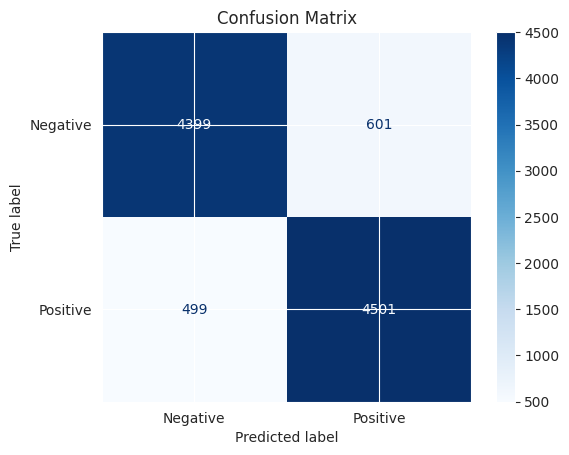

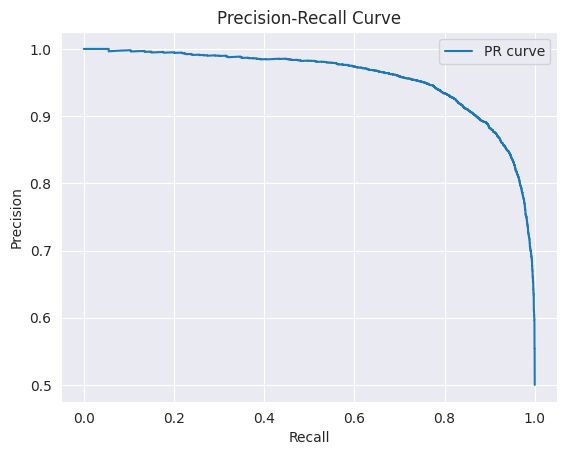

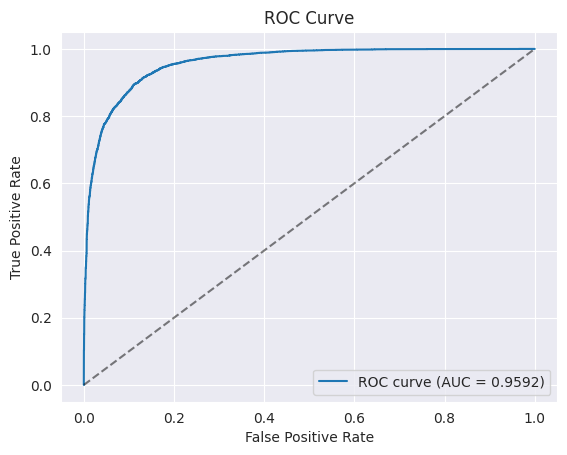

In [11]:
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification Report:\n", report)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

precisions, recalls, pr_thresh = precision_recall_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(recalls, precisions, label='PR curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

fpr, tpr, roc_thresh = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()